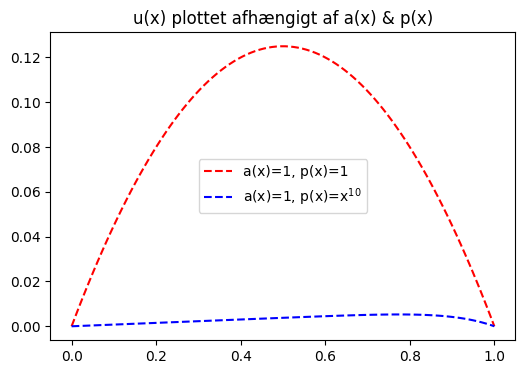

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# Opgave 3 forklarings graf
plt.figure(figsize=(6, 4))
x_values = np.linspace(0,1,100)
def f(x):
    return 5/12*x-1/2*x**2+1/12*x**4

def g(x):
    return x*(1-x)/2

def h(x):
    return 1/(11*12)*x - 1/(11*12)*x**10

plt.plot(x_values,g(x_values),'r--', label="a(x)=1, p(x)=1")

#plt.plot(x_values,g(x_values),'g--')
plt.title("u(x) plottet afhængigt af a(x) & p(x)")
plt.plot(x_values,h(x_values),'b--', label="a(x)=1, p(x)=x$^1$$^0$")
plt.legend()

plt.show()

<Figure size 600x400 with 0 Axes>

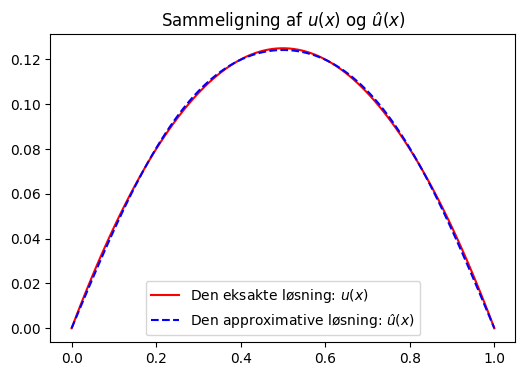

In [2]:
# Opgave 15 graph
plt.figure(figsize=(6, 4))
x_values = np.linspace(0,1,100)

def exact_u(x):
    return x*(1-x)/2

def app_u(x):
    return 4/np.pi**3*(np.sin(np.pi*x)+1/27*np.sin(3*np.pi*x))

plt.figure(figsize=(6, 4))
plt.plot(x_values,exact_u(x_values),'r-', label="Den eksakte løsning: $u(x)$")

#plt.plot(x_values,g(x_values),'g--')
plt.title("Sammeligning af $u(x)$ og $û(x)$")
plt.plot(x_values,app_u(x_values),'b--', label="Den approximative løsning: $û(x)$")
plt.legend()

plt.show()

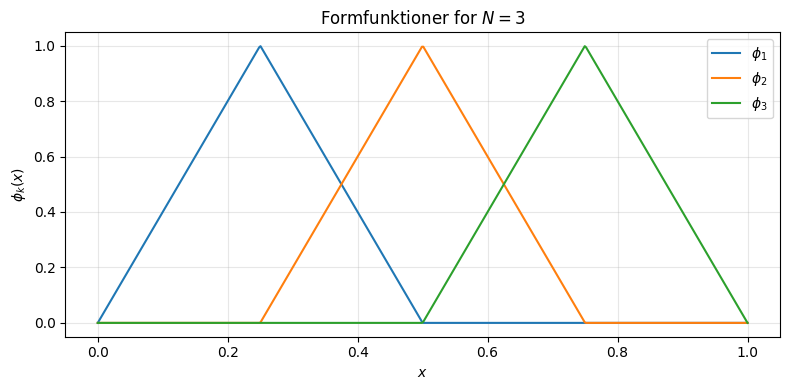

In [3]:
# Opgave 19

N = 3
h = 1.0 / (N + 1)
x_plot = np.linspace(0, 1, 500)

plt.figure(figsize=(8, 4))
for k in range(1, N + 1):
    x_k = k*h  # knudepunktets position
    x_pk = (k+1)*h
    x_mk = (k-1)*h
    phi_k = np.piecewise(x_plot, 
        [(x_plot >= x_mk) & (x_plot < x_k), (x_plot < x_pk) & (x_plot >= x_k)], 
        [lambda x: ((x-x_mk)/(x_k-x_mk)), lambda x: ((x_pk-x)/(x_pk-x_k)), 0])  
        # formfunktionen phi_k
    # 1. (x-h*(k-1))/(x_k-h*(k-1))
    # 2. (h*(k+1)-x)/(h*(k+1)-x_k)
    # 3. 0

    plt.plot(x_plot, phi_k, label=f'$\\phi_{k}$')

plt.xlabel('$x$')
plt.ylabel('$\\phi_k(x)$')
plt.title(f'Formfunktioner for $N = {N}$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Opgave 22
def phi_k(x, k, N):
    h = 1.0 / (N + 1)
    x_k = k*h  # knudepunktets position
    x_pk = (k+1)*h
    x_mk = (k-1)*h
    if x >= x_mk and x < x_k:
        return ((x-x_mk)/(x_k-x_mk))
    elif x >= x_k and x < x_pk:
        return ((x_pk-x)/(x_pk-x_k))
    else:
        return 0

def phi_k_int(x, k, N, high):
    h = 1.0 / (N + 1)
    x_k = k*h  # knudepunktets position
    x_pk = (k+1)*h
    x_mk = (k-1)*h
    if x >= x_mk and x <= x_k and high:
        return (1/(x_k-x_mk))*(1/2*x**2-x_mk*x)
    elif x >= x_k and x <= x_pk:
        return (1/(x_pk-x_k))*(x_pk*x-1/2*x**2)
    else:
        return 0

def phi_k_diff(x, k, N):
    h = 1.0 / (N + 1)
    x_k = k*h  # knudepunktets position
    x_pk = (k+1)*h
    x_mk = (k-1)*h
    if x >= x_mk and x < x_k:
        return (1/(x_k-x_mk))
    elif x >= x_k and x < x_pk:
        return (1/(x_k-x_pk))
    else:
        return 0
def phi_k_diff_int(x, k, N, high):
    h = 1.0 / (N + 1)
    x_k = k*h  # knudepunktets position
    x_pk = (k+1)*h
    x_mk = (k-1)*h
    if x >= x_mk and x <= x_k and high:
        return 
    elif x >= x_k and x <= x_pk:
        return (1/(x_pk-x_k))*(x_pk*x-1/2*x**2)
    else:
        return 0 

def assemble_K(N, a=1.0):
    """Saml stivhedsmatricen K for N indre knudepunkter, konstant a."""
    h = 1.0 / (N + 1)
    K = np.zeros((N, N))
    for k in range(N):
        x_k = (k+1)*h  # knudepunktets position
        x_pk = (k+2)*h
        x_mk = (k)*h
        K[k, k] = a*(1/(x_k-x_mk)-1/(x_k-x_pk))  # diagonalindgang
        if k > 0:
            K[k, k-1] = -1*a/h  # nedre naboindgang
        if k < N - 1:
            K[k, k+1] = -1*a/h  # øvre naboindgang
    return K

def assemble_p(N):
    """Saml lastvektoren p for p(x) = 1."""
    h = 1.0 / (N + 1)  # skridtlængde
    return [h]*N

    p = np.zeros((N))
    for k in range(1, N+1):
        x_k = k*h  # knudepunktets position
        x_pk = (k+1)*h
        x_mk = (k-1)*h
        p[k-1] = phi_k_int(x_k, k, N, 1) - phi_k_int(x_mk, k, N, 1) + phi_k_int(x_pk, k, N, 0) - phi_k_int(x_k, k, N, 0)
    return p  # lastvektor med alle indgange lig h
#print(assemble_p(3))

# Løs og plot for N = 5
N = 20

K = assemble_K(N)  # saml stivhedsmatrixen
p_vec = assemble_p(N)  # saml lastvektoren
#print(K)
#print(p_vec)
u = np.linalg.solve(K, p_vec)
#print(u)

# plot FEM-løsningen sammen med den eksakte løsning

[0.0, 0.047619047619047616, 0.09523809523809523, 0.14285714285714285, 0.19047619047619047, 0.23809523809523808, 0.2857142857142857, 0.3333333333333333, 0.38095238095238093, 0.42857142857142855, 0.47619047619047616, 0.5238095238095237, 0.5714285714285714, 0.6190476190476191, 0.6666666666666666, 0.7142857142857142, 0.7619047619047619, 0.8095238095238095, 0.8571428571428571, 0.9047619047619047, 0.9523809523809523, 1.0]
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


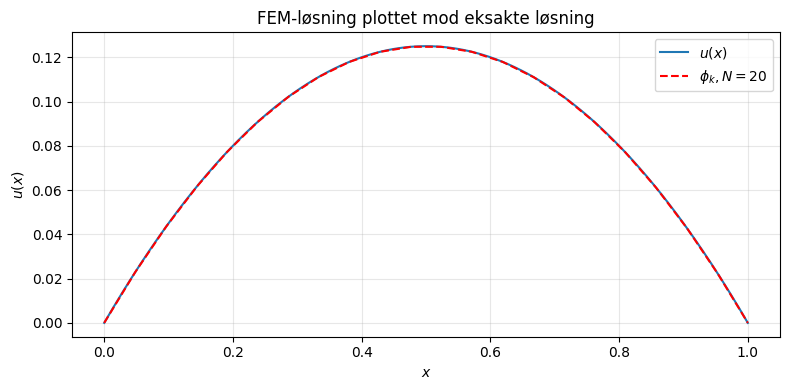

In [5]:
x_plot = np.linspace(0, 1, 500)
from FEM_functions import FEM_y
def exact_u(x):
    return x*(1-x)/2

plt.figure(figsize=(8, 4))
plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.title(f'FEM-løsning plottet mod eksakte løsning')
plt.plot(x_plot, exact_u(x_plot), label='$u(x)$')

#h = 1.0 / (N + 1)  # skridtlængde
#phi = [0]*N
#for k in range(1, N + 1):
#    x_k = k*h  # knudepunktets position
#    x_pk = (k+1)*h
#    x_mk = (k-1)*h
#    phi[k-1] = u[k-1]*np.piecewise(x_plot, 
#        [(x_plot >= x_mk) & (x_plot < x_k), (x_plot < x_pk) & (x_plot >= x_k)], 
#        [lambda x: ((x-x_mk)/(x_k-x_mk)), lambda x: ((x_pk-x)/(x_pk-x_k)), 0])  
    
#def FEM_y(x, u):
#    N = len(u)
#    h = 1.0 / (N + 1)  # skridtlængde
#    phi = [0]*N 
#    for k in range(1, N + 1):
#        x_k = k*h  # knudepunktets position
#        x_pk = (k+1)*h
#        x_mk = (k-1)*h
#        phi[k-1] = u[k-1]*np.piecewise(x_plot, 
#            [(x_plot >= x_mk) & (x_plot < x_k), (x_plot < x_pk) & (x_plot >= x_k)], 
#            [lambda x: ((x-x_mk)/(x_k-x_mk)), lambda x: ((x_pk-x)/(x_pk-x_k)), 0]) 
#    return sum(phi)

plt.plot(x_plot, FEM_y(x_plot, u),'r--', label=f'$\\phi_k, N={N}$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[0.0, 0.1111111111111111, 0.2222222222222222, 0.3333333333333333, 0.4444444444444444, 0.5555555555555556, 0.6666666666666666, 0.7777777777777777, 0.8888888888888888, 1.0]
[0.0, 0.1111111111111111, 0.2222222222222222, 0.3333333333333333, 0.4444444444444444, 0.5555555555555556, 0.6666666666666666, 0.7777777777777777, 0.8888888888888888, 1.0]
1
2
3
4
5
6
7
8


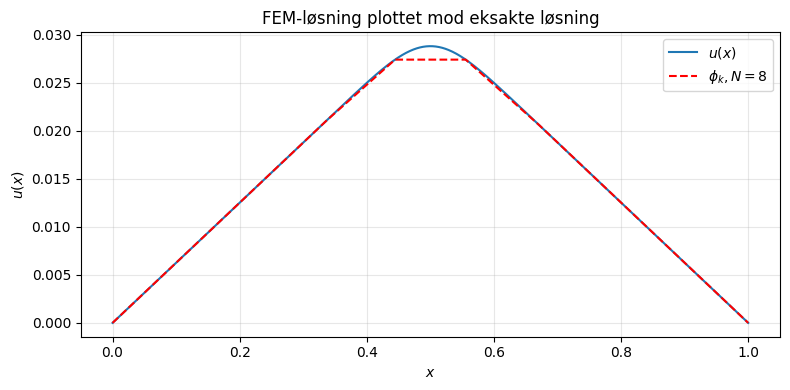

[0.0, 0.2, 0.4, 0.45, 0.48, 0.52, 0.55, 0.6, 0.8, 1.0]
1
2
3
4
5
6
7
8


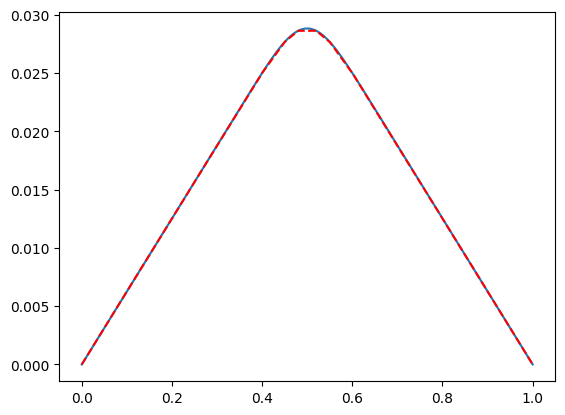

In [6]:
# Opgave 28

from scipy.special import erf
from FEM_functions import *

def u_exact_gaussian(x, sigma=0.05):
    x = np.asarray(x)
    z = (x - 0.5) / (np.sqrt(2) * sigma)
    c = 1 / (2 * np.sqrt(2) * sigma)

    return (
        sigma**2 * (
            np.exp(-1 / (8 * sigma**2))
            - np.exp(-((x - 0.5)**2) / (2 * sigma**2))
        )
        + sigma * np.sqrt(np.pi / 2) * (
            0.5 * erf(c) - (x - 0.5) * erf(z)
        )
    )

N = 8
nodes = [ a*(1/(N+1)) for a in range(N+2) ] # Uniformt net
print(nodes)
a_func = lambda x: 1
p_func = lambda x: np.e**(-1*(x-0.5)**2/(2*0.05**2))

K = assemble_K_general(nodes, a_func)  # saml stivhedsmatrixen
p_vec = assemble_p_general(nodes, p_func)  # saml lastvektoren
u = np.linalg.solve(K, p_vec)

x_plot = np.linspace(0, 1, 1000)
plt.figure(figsize=(8, 4))
plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.title(f'FEM-løsning plottet mod eksakte løsning')
plt.plot(x_plot, u_exact_gaussian(x_plot), label='$u(x)$')
plt.plot(x_plot, FEM_y(x_plot, u, nodes),'r--', label=f'$\\phi_k, N={N}$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

nodes = [0.0, 0.2, 0.4, 0.45, 0.48, 0.52, 0.55, 0.6, 0.8, 1.0]
K = assemble_K_general(nodes, a_func)  # saml stivhedsmatrixen
p_vec = assemble_p_general(nodes, p_func)  # saml lastvektoren
u = np.linalg.solve(K, p_vec)

plt.plot(x_plot, u_exact_gaussian(x_plot), label='$u(x)$')
plt.plot(x_plot, FEM_y(x_plot, u, nodes),'r--', label=f'$\\phi_k, N={N}$')
plt.show()